# Imbalanced Data Handling using SKlearn

In [1]:
import imblearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [3]:
diabetes=pd.read_csv('diabetes.csv')
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
diabetes.shape

(768, 9)

/var/folders/3j/f7d6p9t136x34vdmdy30wrrc0000gn/T/ipykernel_8786/233715427.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(diabetes['Outcome'])


<Axes: xlabel='Outcome'>

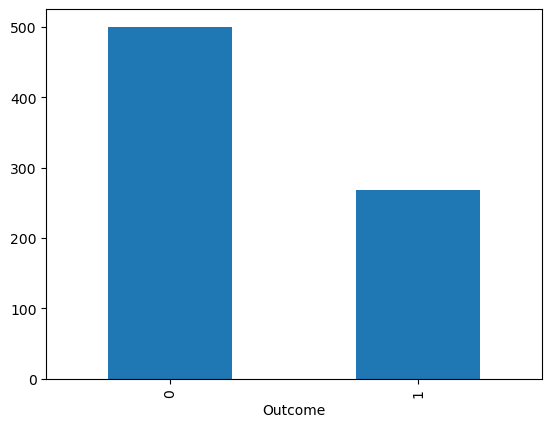

In [5]:
# while there are more imbalanced datasets, we have a significant imbalance
# and the cost of failing to detect the minority class is quite high (lack of diagnosis of diabetes)
count_classes = pd.value_counts(diabetes['Outcome'])
count_classes.plot(kind = 'bar')

In [6]:
X = diabetes.drop('Outcome',axis = 1)
y = diabetes['Outcome']

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# A relatively bad model

In [8]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(max_iter=1000)
LR.fit(X_train, y_train)
LR.score(X_test, y_test)

0.796875

In [10]:
#while accuracy is not absolutely terrible, a closer look reveals some serious problems
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

pred = LR.predict(X_test)

print("precision: ",precision_score(y_test,pred))
print("recall: ",recall_score(y_test,pred))
print("f1: ",f1_score(y_test,pred))


precision:  0.7346938775510204
recall:  0.5806451612903226
f1:  0.6486486486486487


In [11]:
#we fail to identify 40%+ of diabetes cases!
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,pred)

array([[117,  13],
       [ 26,  36]])

# Oversampling / undersampling

In [12]:
from sklearn.utils import resample

In [13]:
# oversampling / undersampling is only to be done on the TRAINING set
# our test set still must reflect reality!
train = pd.concat([X_train, y_train],axis=1)
display(train.shape)
train.head()

(576, 9)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
762,9,89,62,0,0,22.5,0.142,33,0
127,1,118,58,36,94,33.3,0.261,23,0
564,0,91,80,0,0,32.4,0.601,27,0
375,12,140,82,43,325,39.2,0.528,58,1
663,9,145,80,46,130,37.9,0.637,40,1


## Oversampling

In [14]:
# separate majority/minority classes
no_diabetes = train[train['Outcome']==0]
yes_diabetes = train[train['Outcome']==1]

In [15]:
display(no_diabetes.shape)
display(yes_diabetes.shape)

(370, 9)

(206, 9)

In [16]:
# oversample minority
yes_diabetes_oversampled = resample(yes_diabetes, #<- sample from here
                                    replace=True, #<- we need replacement, since we don't have enough data otherwise
                                    n_samples = len(no_diabetes),#<- make both sets the same size
                                    random_state=0)

In [17]:
# both sets are now of a reasonable size
display(no_diabetes.shape)
display(yes_diabetes_oversampled.shape)

(370, 9)

(370, 9)

In [18]:
train_oversampled = pd.concat([no_diabetes,yes_diabetes_oversampled])
train_oversampled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
762,9,89,62,0,0,22.5,0.142,33,0
127,1,118,58,36,94,33.3,0.261,23,0
564,0,91,80,0,0,32.4,0.601,27,0
144,4,154,62,31,284,32.8,0.237,23,0
268,0,102,52,0,0,25.1,0.078,21,0


In [19]:
y_train_over = train_oversampled['Outcome'].copy()
X_train_over = train_oversampled.drop('Outcome',axis = 1).copy()

In [20]:
# Our Logistic Regression, while still not amazing, has improved substantially!
# especially at detecting instances of diabetes
LR = LogisticRegression(max_iter=1000)
LR.fit(X_train_over, y_train_over)
pred = LR.predict(X_test)

print("precision: ",precision_score(y_test,pred))
print("recall: ",recall_score(y_test,pred))
print("f1: ",f1_score(y_test,pred))

precision:  0.6388888888888888
recall:  0.7419354838709677
f1:  0.6865671641791045


In [21]:
confusion_matrix(y_test,pred)

array([[104,  26],
       [ 16,  46]])

## Undersampling

In [22]:
# undersample majority
no_diabetes_undersampled = resample(no_diabetes, #<- downsample from here
                                    replace=False, #<- no need to reuse data now, we have an abundance
                                    n_samples = len(yes_diabetes),
                                    random_state=0)

In [23]:
# both sets are the same size
# small, but balanced, and no repeated data
display(yes_diabetes.shape)
display(no_diabetes_undersampled.shape)

(206, 9)

(206, 9)

In [24]:
train_undersampled = pd.concat([yes_diabetes,no_diabetes_undersampled])
train_undersampled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
375,12,140,82,43,325,39.2,0.528,58,1
663,9,145,80,46,130,37.9,0.637,40,1
255,1,113,64,35,0,33.6,0.543,21,1
312,2,155,74,17,96,26.6,0.433,27,1
109,0,95,85,25,36,37.4,0.247,24,1


In [25]:
y_train_under = train_undersampled['Outcome'].copy()
X_train_under = train_undersampled.drop('Outcome',axis = 1).copy()

In [26]:
# Still a slight improvement!
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(max_iter=1000)
LR.fit(X_train_under, y_train_under)
pred = LR.predict(X_test)

print("precision: ",precision_score(y_test,pred))
print("recall: ",recall_score(y_test,pred))
print("f1: ",f1_score(y_test,pred))

precision:  0.6438356164383562
recall:  0.7580645161290323
f1:  0.6962962962962963


In [27]:
confusion_matrix(y_test,pred)

array([[104,  26],
       [ 15,  47]])

# SMOTE

In [28]:
from imblearn.over_sampling import SMOTE

In [29]:
# a bit of magic, you can find documentation here: https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html
# by deafult, takes a 5-neightbour KNN to build a new point
sm = SMOTE(random_state = 123,sampling_strategy=1.0)
X_train_SMOTE,y_train_SMOTE = sm.fit_resample(X_train,y_train)

In [30]:
X_train_SMOTE

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,9,89,62,0,0,22.500000,0.142000,33
1,1,118,58,36,94,33.300000,0.261000,23
2,0,91,80,0,0,32.400000,0.601000,27
3,12,140,82,43,325,39.200000,0.528000,58
4,9,145,80,46,130,37.900000,0.637000,40
...,...,...,...,...,...,...,...,...
735,2,82,40,36,93,42.027092,0.361947,26
736,4,123,74,0,0,33.983012,0.221408,37
737,1,162,63,37,0,43.028040,0.516639,24
738,2,78,49,32,88,31.940887,0.257723,26


In [32]:
# yet another small improvement, but bear in mind that we saved 12 hypothetical people with
# these "small improvements"
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(max_iter=1000)
LR.fit(X_train_SMOTE, y_train_SMOTE)
pred = LR.predict(X_test)

print("precision: ",precision_score(y_test,pred))
print("recall: ",recall_score(y_test,pred))
print("f1: ",f1_score(y_test,pred))

precision:  0.631578947368421
recall:  0.7741935483870968
f1:  0.6956521739130435


In [33]:
confusion_matrix(y_test,pred)

array([[102,  28],
       [ 14,  48]])